# **` Consumo de API climática`**

In [ ]:
#pip install requests
import pandas as pd

In [ ]:
import requests

url = "http://api.openweathermap.org/data/2.5/weather?q=Medellin,CO&APPID=edf40d9623a8977cd0d82d5ea6c96e0d"  #Este endpoint fue dado por openweathermap.org


response = requests.get(url, headers=headers)
print(response.json()) # codigo 200, exitosa.

# Se observa el JSON para ver la estructura de la respuesta de la API

{'coord': {'lon': -75.5636, 'lat': 6.2518}, 'weather': [{'id': 800, 'main': 'Clear', 'description': 'clear sky', 'icon': '01n'}], 'base': 'stations', 'main': {'temp': 291.6, 'feels_like': 291.88, 'temp_min': 291.25, 'temp_max': 292.41, 'pressure': 1016, 'humidity': 91, 'sea_level': 1016, 'grnd_level': 807}, 'visibility': 10000, 'wind': {'speed': 2.24, 'deg': 330, 'gust': 0}, 'clouds': {'all': 0}, 'dt': 1775270207, 'sys': {'type': 2, 'id': 2099918, 'country': 'CO', 'sunrise': 1775213978, 'sunset': 1775257863}, 'timezone': -18000, 'id': 3674962, 'name': 'Medellín', 'cod': 200}


In [ ]:
ciudades =["Cali,CO","Medellin,CO","Bogota,CO"] #Las 3 ciudades más grandes de Colombia
rows= []

for c in ciudades:
    url = f"http://api.openweathermap.org/data/2.5/weather?q={c}&APPID=edf40d9623a8977cd0d82d5ea6c96e0d&units=metric"   # Se realiza llamado a la API con todas las ciudades (3)
    res = requests.get(url).json() #Recibir el json que se recibe desde la API con metodo GET

    rows.append({
        "ciudad": res["name"],
        "pais": res["sys"]["country"],
        "lat": res["coord"]["lat"],
        "lon": res["coord"]["lon"],
        "temperatura": res["main"]["temp"],
        "sensacion_termica": res["main"]["feels_like"],     ## Se adicionan a la lista 'rows' las columnas relevantes y los valores de cada ciudad
        "temp_min": res["main"]["temp_min"],
        "temp_max": res["main"]["temp_max"],
        "humedad": res["main"]["humidity"],
        "presion": res["main"]["pressure"],
        "clima": res["weather"][0]["main"],
        "nubosidad": res["clouds"]["all"],
        "viento": res["wind"]["speed"]
    })

df = pd.DataFrame(rows) #creacion del conjunto de datos con la lista 'rows' (que incluye las columnas)
print(df)

             ciudad pais     lat      lon  temperatura  sensacion_termica  \
0  Santiago de Cali   CO  3.4372 -76.5225        24.00              24.26   
1          Medellín   CO  6.2518 -75.5636        18.45              18.73   
2            Bogota   CO  4.6097 -74.0817        15.06              14.76   

   temp_min  temp_max  humedad  presion   clima  nubosidad  viento  
0     24.00     24.00       69     1013  Clouds         20    3.60  
1     18.10     19.26       91     1016   Clear          0    2.24  
2     14.53     15.38       82     1018  Clouds        100    1.10  


Se ha creado un dataframe con datos metereológicos de las 3 ciudades más grandes de Colombia, los datos son obtenidos en tiempos cercanos al real (3/04/2026 9:09 PM)

In [ ]:
from datetime import datetime
from zoneinfo import ZoneInfo

# Obtener la hora actual en una zona específica
ahora_bogota = datetime.now(ZoneInfo("America/Bogota"))

##AÑO-MES-DIA HORA.MINUTO:SEGUNDO.MILISEGUNDO
print(ahora_bogota)

2026-04-03 21:36:47.450315-05:00


##Unidades

`Es importante tener en cuenta las unidades:`  
temperatura: °C  
sensacion_termica: °C  
temp_min: °C  
temp_max: °C  
humedad: %  
presion: hPa
viento: m/s  
nubosidad: %  
lat: °  
lon: °  
dt: s (timestamp UNIX)    
sunrise: s (timestamp UNIX)  
sunset: s (timestamp UNIX)  


Estas se pudieron apreciar en el JSON recibido por el metodo GET


##Visualizaciones

A CONTINUACIÓN SE MUESTRAN VISUALIZACIONES DE LOS DATOS OBTENIDOS

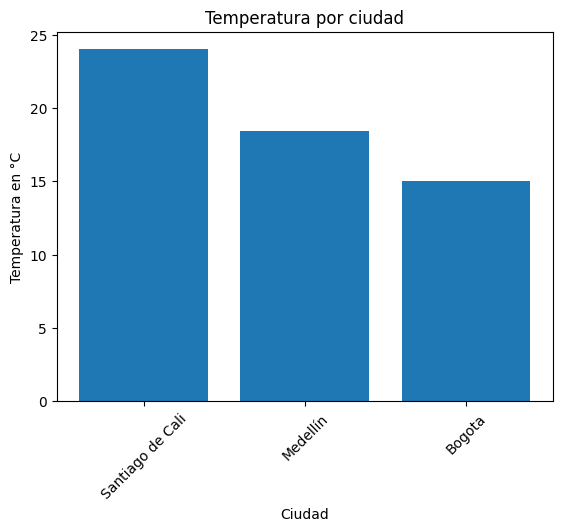

In [ ]:
#TEMPERATURA POR CIUDAD
import matplotlib.pyplot as plt

plt.figure()
plt.bar(df["ciudad"], df["temperatura"])
plt.title("Temperatura por ciudad")
plt.xlabel("Ciudad")
plt.ylabel("Temperatura en °C")
plt.xticks(rotation=45)
plt.show()

La ciudad mas caliente es Cali, luego Medellin y de último Bogotá

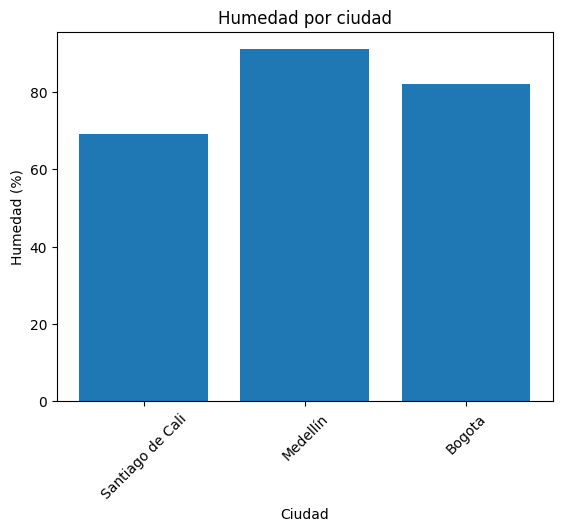

In [ ]:
plt.figure()
plt.bar(df["ciudad"], df["humedad"])
plt.title("Humedad por ciudad")
plt.xlabel("Ciudad")
plt.ylabel("Humedad (%)")
plt.xticks(rotation=45)
plt.show()

La ciudad con más humedad es Cali

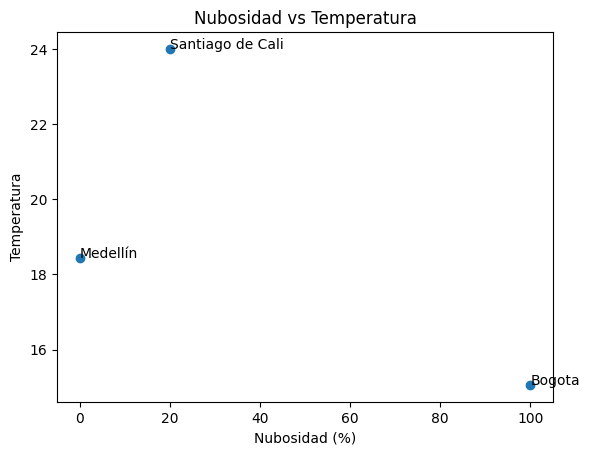

In [ ]:
plt.figure()
plt.scatter(df["nubosidad"], df["temperatura"])
plt.title("Nubosidad vs Temperatura")
plt.xlabel("Nubosidad (%)")
plt.ylabel("Temperatura")

for i, txt in enumerate(df["ciudad"]):
    plt.annotate(txt, (df["nubosidad"][i], df["temperatura"][i]))

plt.show()

- Bogotá tiene mucha más nubosidad que las otras 2 ciudades, pero es la más fría.
- Medellin tiene la mayor temperatura y la nubosidad es intermedia entre las 3 ciudades

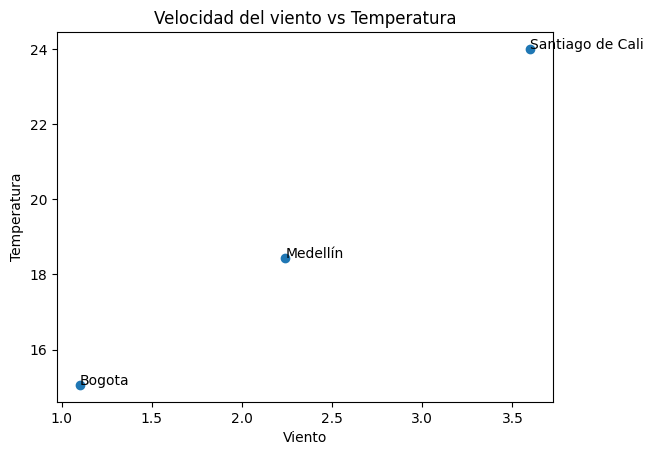

In [ ]:
plt.figure()
plt.scatter(df["viento"], df["temperatura"])
plt.title("Velocidad del viento vs Temperatura")
plt.xlabel("Viento")
plt.ylabel("Temperatura")

for i, txt in enumerate(df["ciudad"]):
    plt.annotate(txt, (df["viento"][i], df["temperatura"][i]))

plt.show()

Se podría decir que existe una relación entre vel. del viento y la temperatura (Solo con estas 3 ciudades), la linealidad real es más "empinada" teniendo en cuenta las escalas de los ejes.